# 🎮 Game Sales Analysis

## 📊 Overview
This project analyzes video game sales data to identify trends in consoles, genres, and global market performance using Python.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 📂 1. Loading the Dataset

We begin by loading the video game sales dataset into a Pandas DataFrame.

In [2]:
df = pd.read_csv('vgchartz-2024.csv')

In [3]:
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


## 🔍 2. Data Exploration

We inspect the dataset structure, summary statistics, and missing values to understand the data quality.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [5]:
df.describe()

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000


In [6]:
df.isnull().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

In [7]:
df.columns

Index(['img', 'title', 'console', 'genre', 'publisher', 'developer',
       'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales',
       'other_sales', 'release_date', 'last_update'],
      dtype='object')

## 🧹 3. Data Cleaning

We clean the dataset by selecting relevant columns, handling missing values, and formatting dates for analysis.

In [8]:
df = df[['title',
        'genre',
        'console',
         'critic_score',
         'total_sales',
         'na_sales',
         'jp_sales',
         'pal_sales',
         'other_sales',
         'release_date'
        ]]

In [9]:
df = df.dropna(subset=['total_sales'])
df_critic = df.dropna(subset=['critic_score'])
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

## 📊 4. Analysis

We analyze top-selling games, consoles, genres, regional sales, and relationships between critic scores and sales.

### 🎮 Top Selling Games

In [10]:
df.sort_values(by='total_sales', ascending=False).head(10)

,title,genre,console,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,year
0,Grand Theft Auto V,Action,PS3,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,2013.0
1,Grand Theft Auto V,Action,PS4,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2014.0
2,Grand Theft Auto: Vice City,Action,PS2,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,2002.0
3,Grand Theft Auto V,Action,X360,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,2013.0
4,Call of Duty: Black Ops 3,Shooter,PS4,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2015.0
5,Call of Duty: Modern Warfare 3,Shooter,X360,8.7,14.82,9.07,0.13,4.29,1.33,2011-11-08,2011.0
6,Call of Duty: Black Ops,Shooter,X360,8.8,14.74,9.76,0.11,3.73,1.14,2010-11-09,2010.0
7,Red Dead Redemption 2,Action-Adventure,PS4,9.8,13.94,5.26,0.21,6.21,2.26,2018-10-26,2018.0
8,Call of Duty: Black Ops II,Shooter,X360,8.4,13.86,8.27,0.07,4.32,1.20,2012-11-13,2012.0
9,Call of Duty: Black Ops II,Shooter,PS3,8.0,13.80,4.99,0.65,5.88,2.28,2012-11-13,2012.0


### 🎮 Best Performing Consoles

In [11]:
df.groupby('console')['total_sales'].sum().sort_values(ascending=False).head(10)

console
PS2     1027.76
X360     859.79
PS3      839.70
PS       546.25
PS4      539.92
Wii      459.44
DS       458.17
XOne     268.96
PSP      245.29
XB       232.05
Name: total_sales, dtype: float64

In [21]:
df.groupby('console')['total_sales'].mean().sort_values(ascending=False).head(10)

console
GBC     1.446667
NES     0.998542
GEN     0.697407
X360    0.660361
PS3     0.622923
2600    0.600476
PS4     0.594626
XOne    0.513282
PS2     0.483424
PS      0.483407
Name: total_sales, dtype: float64

This shows average performance per game, removing bias from older consoles

### 🎮 Genre Performance

In [12]:
df.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

genre
Sports              1187.51
Action              1125.89
Shooter              995.50
Misc                 557.79
Racing               525.75
Role-Playing         426.80
Platform             349.15
Fighting             341.13
Adventure            325.39
Simulation           300.65
Action-Adventure     148.52
Puzzle               127.28
Strategy             118.31
Music                 51.75
MMO                    9.31
Party                  6.21
Visual Novel           5.78
Sandbox                1.89
Education              0.97
Board Game             0.33
Name: total_sales, dtype: float64

### 🌍 Regional Sales Breakdown

In [13]:
region_sales = df[['na_sales', 'jp_sales', 'pal_sales', 'other_sales']].sum()
region_sales.sort_values(ascending=False)

na_sales       3345.52
pal_sales      1916.83
jp_sales        687.94
other_sales     651.12
dtype: float64

### ⭐ Critic Score vs Sales Relationship

In [14]:
df_critic[['critic_score', 'total_sales']].corr()

,critic_score,total_sales
critic_score,1.000000,0.281166
total_sales,0.281166,1.000000


## 📊 5. Visualizations
We now visualize key insights using charts.

### 🎮 Sales by Console

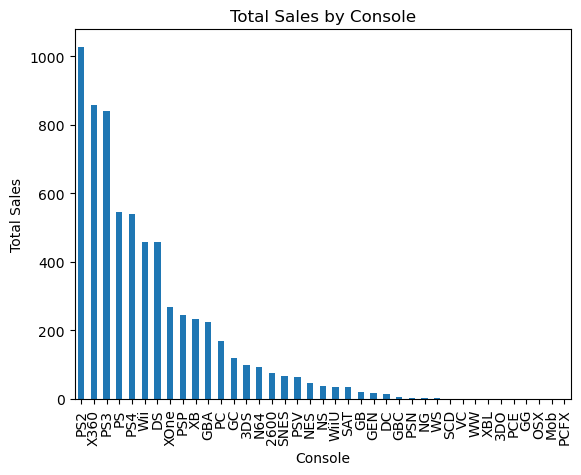

In [15]:
console_sales = df.groupby('console')['total_sales'].sum().sort_values(ascending=False)
console_sales.plot(kind='bar')
plt.title('Total Sales by Console')
plt.xlabel('Console')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show()

PS2 leads total sales, followed by Xbox 360 and PS3. This suggests that consoles with longer lifespans accumulate higher total sales.

### 🎮 Sales by Genre

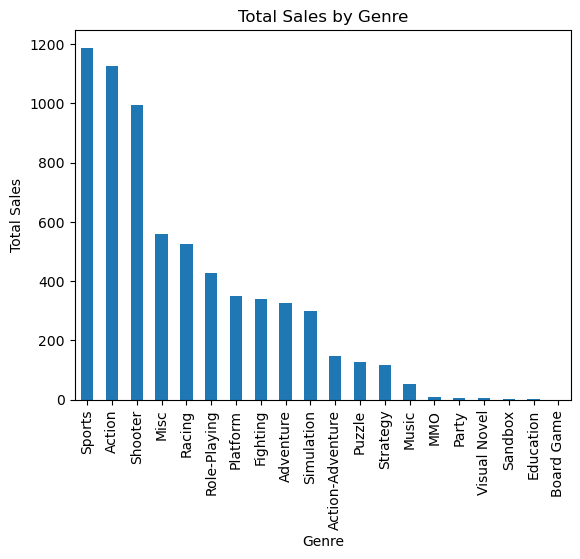

In [16]:
genre_sales = df.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_sales.plot(kind='bar')
plt.title('Total Sales by Genre')
plt.xlabel('Genre')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show()

### 📈 Sales Over Time

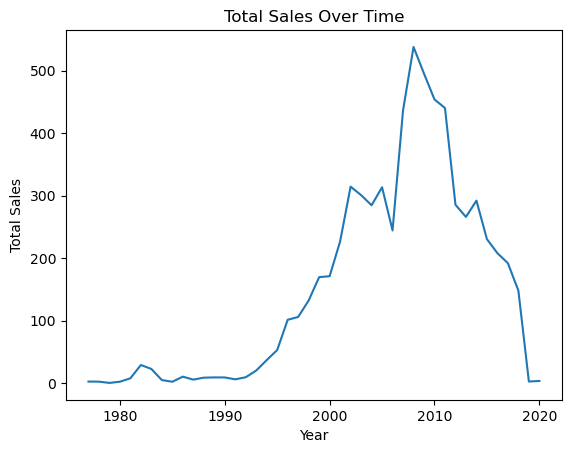

In [17]:
year_sales = df.groupby('year')['total_sales'].sum().sort_index()

year_sales.plot(kind='line')
plt.title('Total Sales Over Time')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.show()

Sales increased rapidly from 2008 and peaked around 2014, followed by a gradual decline.

### 📉 Critic Score vs Sales

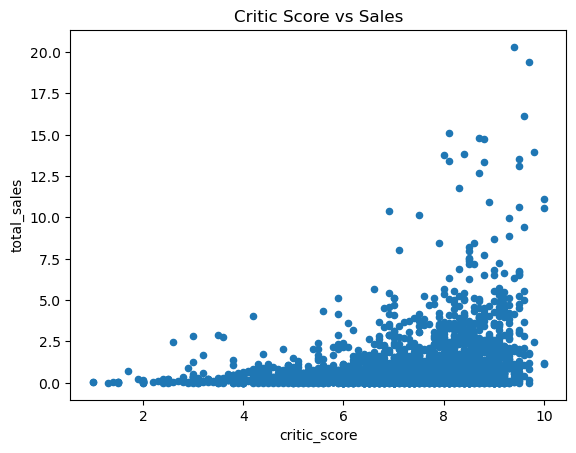

In [18]:
df_critic.plot.scatter(x='critic_score', y='total_sales')
plt.title('Critic Score vs Sales')
plt.show()

## 💡 Key Insights

- Older consoles such as PS2, Xbox 360, and PS3 dominate total sales due to longer market presence- Sales peaked around 2014 before declining
- Action and Sports are the top-selling genres
- North America is the largest market
- Critic scores have a weak positive impact on sales (~0.32)

---

## ⚠️ Limitations

- Dataset reduced due to missing values
- Only includes games with complete sales data
- Results may not represent full industry trends